In [6]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Load model
detector = hub.load("https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1")

In [12]:
# Load image
img_path = "/Users/rajanthakulla/Desktop/computer vision research/dog.png"  # your test image
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
input_tensor = tf.convert_to_tensor(img_rgb)[tf.newaxis, ...]


In [13]:
# Run detection
result = detector(input_tensor)
boxes, scores, classes = result["detection_boxes"][0], result["detection_scores"][0], result["detection_classes"][0]

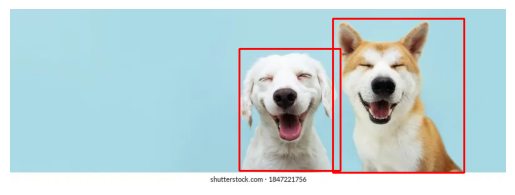

In [14]:
# Draw bounding boxes
h, w, _ = img.shape
for i in range(len(scores)):
    if scores[i] > 0.5:
        ymin, xmin, ymax, xmax = boxes[i]
        cv2.rectangle(img_rgb, (int(xmin*w), int(ymin*h)), (int(xmax*w), int(ymax*h)), (255,0,0), 2)

plt.imshow(img_rgb); plt.axis("off"); plt.show()
